In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [ ]:
x,y = make_blobs(n_samples=115,centers=2,n_features=2)

In [ ]:
y = y.reshape(-1,1)

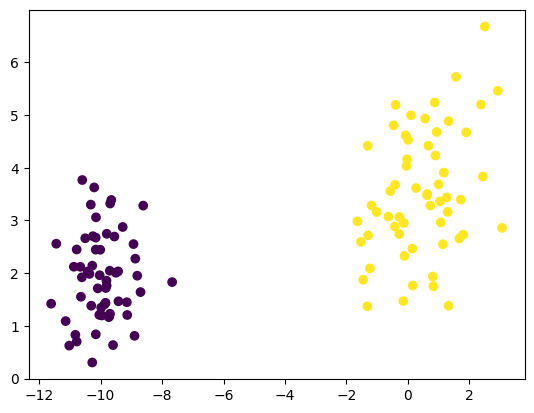

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)

plt.show()

In [ ]:
x = torch.tensor(x,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=43)

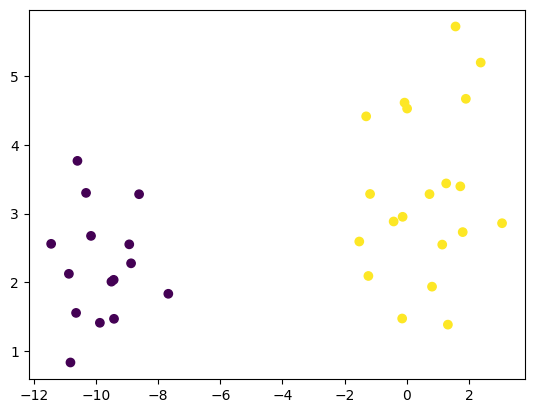

In [ ]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test)
plt.show()

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_features=input, out_features=8)
        self.fc2 = torch.nn.Linear(in_features=8, out_features=output)
        self.act =torch.nn.Sigmoid()
        # Activation function


    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)

        # out = torch.sigmoid(x)
        out = self.act(x)
        return out

In [ ]:
model = Net(2,1)

In [ ]:
criterion = torch.nn.BCELoss()
lr = 0.01
optimizer = torch.optim.Adam(model.parameters(),lr=lr)

In [ ]:
epochs=10
for epoch in range(epochs):

    # Clear the previous gradients to avoid accumulation
    optimizer.zero_grad()

    # Calculate predicted values
    y_hat = model(x_train)

    # Compute the loss between predicted values and actual targets
    loss = criterion(y_hat, y_train)
    # Compute gradients of the loss with respect to model parameters
    loss.backward()

    # Update the model parameters using the computed gradients
    optimizer.step()
    pred = model(x_test)
    if epoch%1==0:
        print(f'epoch {epoch}\t loss:\t{loss.item()}')

epoch 0	 loss:	0.7405028939247131
epoch 1	 loss:	0.6382113695144653
epoch 2	 loss:	0.5497856736183167
epoch 3	 loss:	0.47374653816223145
epoch 4	 loss:	0.40850478410720825
epoch 5	 loss:	0.3526748716831207
epoch 6	 loss:	0.30504998564720154
epoch 7	 loss:	0.2645159065723419
epoch 8	 loss:	0.2300560474395752
epoch 9	 loss:	0.2007661759853363


In [ ]:
pred = model(x_test)>0.5

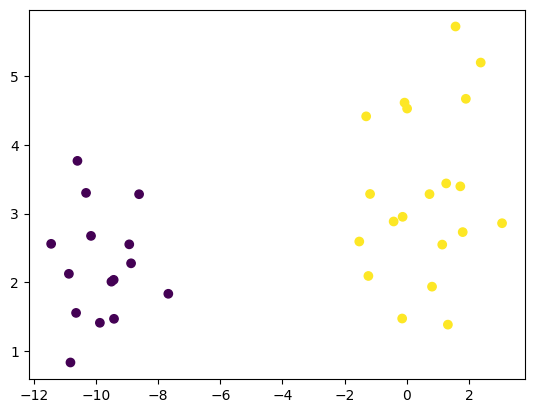

In [ ]:
plt.scatter(x_test[:,0],x_test[:,1],c=pred.detach().numpy())
plt.show()

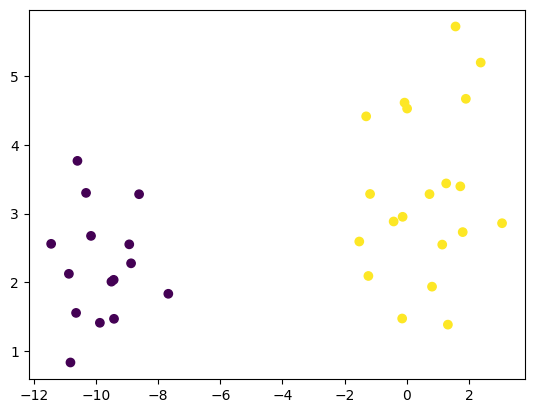

In [ ]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test)
plt.show()